In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set(style='whitegrid')
plt.rcParams.update({'figure.dpi': 120, 'axes.titlesize': 12})

# File paths
R_FILE = r'C:\AMR_Prediction_Project\Data\isolates_ecoli_R.csv'
S_FILE = r'C:\AMR_Prediction_Project\Data\isolates_ecoli_S.csv'

# Colour scheme used throughout
COLORS = {'Resistant': '#D85A30', 'Susceptible': '#1D9E75'}

print('Setup complete')

Setup complete


In [2]:
# Load both files
df_R = pd.read_csv(R_FILE)
df_S = pd.read_csv(S_FILE)

# Strip whitespace from column names (common NCBI formatting issue)
df_R.columns = df_R.columns.str.strip()
df_S.columns = df_S.columns.str.strip()

print('=== RAW DATA LOADED ===')
print(f'Resistant  : {len(df_R):,} isolates')
print(f'Susceptible: {len(df_S):,} isolates')
print(f'Total      : {len(df_R) + len(df_S):,} isolates')

=== RAW DATA LOADED ===
Resistant  : 1,765 isolates
Susceptible: 9,607 isolates
Total      : 11,372 isolates


In [3]:
# Dataset structure for resistant file
print('=== RESISTANT FILE STRUCTURE ===')
df_R.info()
print()
print('=== SUSCEPTIBLE FILE STRUCTURE ===')
df_S.info()

=== RESISTANT FILE STRUCTURE ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1765 entries, 0 to 1764
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   #Organism group      1765 non-null   object 
 1   Strain               1172 non-null   object 
 2   Isolate identifiers  1765 non-null   object 
 3   Serovar              0 non-null      float64
 4   Isolate              1765 non-null   object 
 5   Create date          1765 non-null   object 
 6   Location             1693 non-null   object 
 7   Isolation source     1680 non-null   object 
 8   Isolation type       1765 non-null   object 
 9   Food origin          240 non-null    object 
 10  SNP cluster          1088 non-null   object 
 11  Min-same             1046 non-null   float64
 12  Min-diff             485 non-null    float64
 13  BioSample            1765 non-null   object 
 14  Assembly             1606 non-null   object 
 15  AMR g

In [4]:
# Missing values in key columns used for filtering
# Assembly is critical — without it we cannot download the genome
# AST phenotypes is critical — it tells us R or S for each antibiotic
print('=== MISSING VALUES (top 10 columns) ===')
print('\nResistant file:')
print(df_R.isnull().sum().sort_values(ascending=False).head(10))
print('\nSusceptible file:')
print(df_S.isnull().sum().sort_values(ascending=False).head(10))

=== MISSING VALUES (top 10 columns) ===

Resistant file:
Computed types      1765
Serovar             1765
Food origin         1525
Min-diff            1280
Min-same             719
SNP cluster          677
Strain               593
Assembly             159
Isolation source      85
Location              72
dtype: int64

Susceptible file:
Computed types      9607
Serovar             9607
Min-diff            7977
Food origin         7918
Min-same            5215
SNP cluster         4936
Strain              1091
Assembly             417
AMR genotypes        295
Isolation source     132
dtype: int64


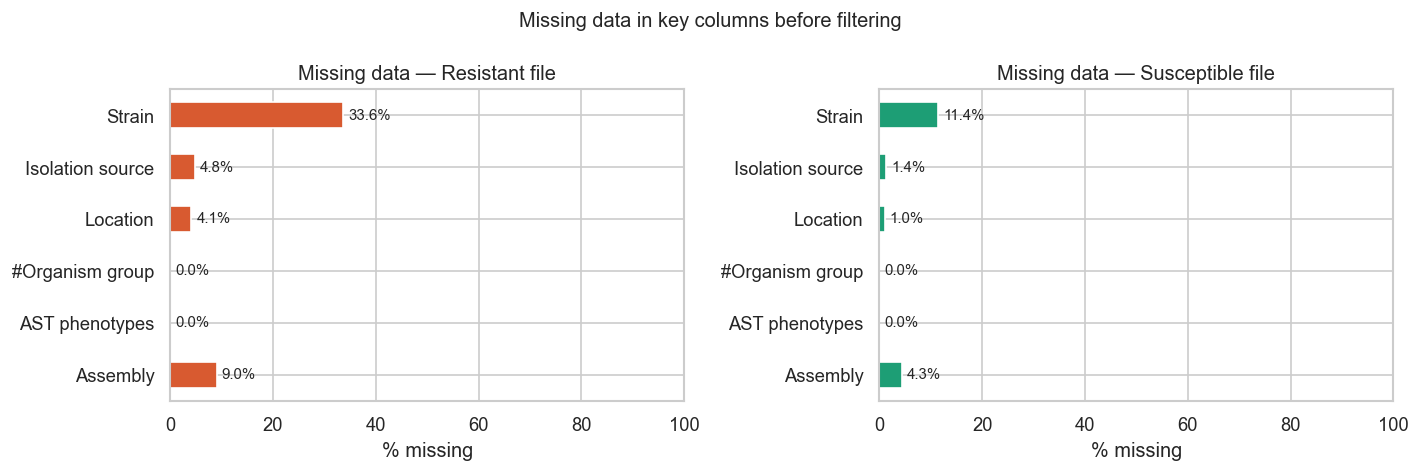

Note: Assembly missing means we cannot download that genome — these will be removed.


In [5]:
# Visualize missing data percentage for key columns
key_cols = ['Assembly', 'AST phenotypes', '#Organism group',
            'Location', 'Isolation source', 'Strain']

miss_r = df_R[key_cols].isnull().mean() * 100
miss_s = df_S[key_cols].isnull().mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, miss, title in zip(axes,
                            [miss_r, miss_s],
                            ['Resistant file', 'Susceptible file']):
    miss.plot(kind='barh', ax=ax, color='#D85A30' if 'Resist' in title else '#1D9E75')
    ax.set_xlabel('% missing')
    ax.set_title(f'Missing data — {title}')
    ax.set_xlim(0, 100)
    for i, v in enumerate(miss):
        ax.text(v + 1, i, f'{v:.1f}%', va='center', fontsize=9)

plt.suptitle('Missing data in key columns before filtering', fontsize=12)
plt.tight_layout()
plt.show()
print('Note: Assembly missing means we cannot download that genome — these will be removed.')

In [6]:
# What organisms are actually in the raw files?
# The files were labelled as E. coli but may contain related species (e.g. Shigella)
print('=== ORGANISM TYPES IN RAW FILES ===')
print('\nResistant file — top organisms:')
print(df_R['#Organism group'].value_counts().head(8))
print('\nSusceptible file — top organisms:')
print(df_S['#Organism group'].value_counts().head(8))

=== ORGANISM TYPES IN RAW FILES ===

Resistant file — top organisms:
E.coli and Shigella     1472
Campylobacter jejuni     293
Name: #Organism group, dtype: int64

Susceptible file — top organisms:
E.coli and Shigella     8203
Campylobacter jejuni    1404
Name: #Organism group, dtype: int64


In [7]:
r_before = len(df_R)
s_before = len(df_S)

# Filter to E. coli only (case-insensitive match on 'coli')
df_R = df_R[df_R['#Organism group'].str.contains('coli', case=False, na=False)]
df_S = df_S[df_S['#Organism group'].str.contains('coli', case=False, na=False)]

print('=== AFTER ORGANISM FILTER ===')
print(f'Resistant  : {r_before:,} → {len(df_R):,}  (removed {r_before - len(df_R):,})')
print(f'Susceptible: {s_before:,} → {len(df_S):,}  (removed {s_before - len(df_S):,})')

=== AFTER ORGANISM FILTER ===
Resistant  : 1,765 → 1,472  (removed 293)
Susceptible: 9,607 → 8,203  (removed 1,404)


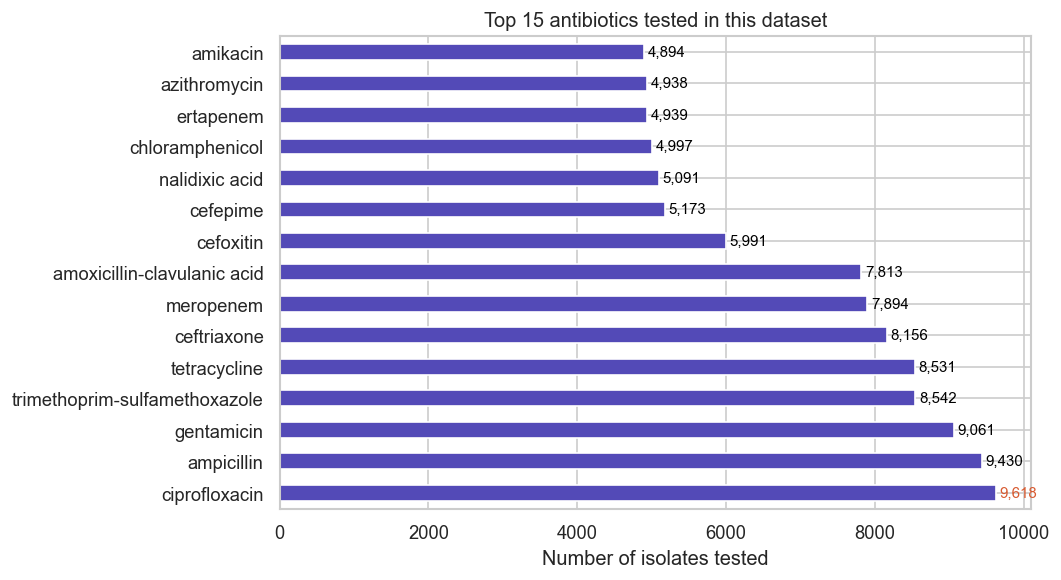

Ciprofloxacin isolate count: 9,618


In [9]:
# Count how many isolates have each antibiotic tested
# Combine both files temporarily for this overview
all_phenotypes = pd.concat([df_R['AST phenotypes'], df_S['AST phenotypes']]).dropna()

# Extract individual antibiotic names
antibiotic_list = []
for row in all_phenotypes:
    for pair in str(row).split(','):
        ab = pair.split('=')[0].strip().lower()
        if ab:
            antibiotic_list.append(ab)

ab_counts = pd.Series(antibiotic_list).value_counts().head(15)

fig, ax = plt.subplots(figsize=(9, 5))
ab_counts.plot(kind='barh', ax=ax, color='#534AB7')
ax.set_xlabel('Number of isolates tested')
ax.set_title('Top 15 antibiotics tested in this dataset')
# Highlight ciprofloxacin
for i, (label, val) in enumerate(ab_counts.items()):
    color = '#D85A30' if label == 'ciprofloxacin' else 'black'
    ax.text(val + 50, i, f'{val:,}', va='center', fontsize=9, color=color)
plt.tight_layout()
plt.show()
print(f'Ciprofloxacin isolate count: {ab_counts.get("ciprofloxacin", 0):,}')

In [8]:
# Show what an AST phenotype string looks like
print('Example AST phenotype strings:')
print(df_R['AST phenotypes'].dropna().head(3).to_string())

Example AST phenotype strings:
293    amikacin=S,amoxicillin-clavulanic acid=R,amoxi...
294    amikacin=S,amoxicillin-clavulanic acid=R,ampic...
295    amoxicillin-clavulanic acid=S,ampicillin=R,azi...


In [10]:
r_before = len(df_R)
s_before = len(df_S)

# Keep only isolates explicitly confirmed for ciprofloxacin
# \b = word boundary ensures we match 'ciprofloxacin=R' not 'methyl-ciprofloxacin=R'
df_R = df_R[df_R['AST phenotypes'].str.contains(r'ciprofloxacin=R\b', na=False)]
df_S = df_S[df_S['AST phenotypes'].str.contains(r'ciprofloxacin=S\b', na=False)]

print('=== AFTER CIPROFLOXACIN FILTER ===')
print(f'Resistant  : {r_before:,} → {len(df_R):,}  (removed {r_before - len(df_R):,})')
print(f'Susceptible: {s_before:,} → {len(df_S):,}  (removed {s_before - len(df_S):,})')

=== AFTER CIPROFLOXACIN FILTER ===
Resistant  : 1,472 → 1,472  (removed 0)
Susceptible: 8,203 → 6,519  (removed 1,684)


In [11]:
r_before = len(df_R)
s_before = len(df_S)

print('Missing assemblies before removal:')
print(f'  Resistant  : {df_R["Assembly"].isna().sum():,}')
print(f'  Susceptible: {df_S["Assembly"].isna().sum():,}')

# Remove rows with no assembly accession
df_R = df_R[df_R['Assembly'].notna()]
df_S = df_S[df_S['Assembly'].notna()]

print(f'\nAfter assembly filter:')
print(f'Resistant  : {r_before:,} → {len(df_R):,}  (removed {r_before - len(df_R):,})')
print(f'Susceptible: {s_before:,} → {len(df_S):,}  (removed {s_before - len(df_S):,})')

Missing assemblies before removal:
  Resistant  : 158
  Susceptible: 235

After assembly filter:
Resistant  : 1,472 → 1,314  (removed 158)
Susceptible: 6,519 → 6,284  (removed 235)


In [12]:
r_before = len(df_R)
s_before = len(df_S)

print('Duplicate assemblies before removal:')
print(f'  Resistant  : {df_R["Assembly"].duplicated().sum():,}')
print(f'  Susceptible: {df_S["Assembly"].duplicated().sum():,}')

df_R = df_R.drop_duplicates(subset=['Assembly'])
df_S = df_S.drop_duplicates(subset=['Assembly'])

print(f'\nAfter duplicate removal:')
print(f'Resistant  : {r_before:,} → {len(df_R):,}  (removed {r_before - len(df_R):,})')
print(f'Susceptible: {s_before:,} → {len(df_S):,}  (removed {s_before - len(df_S):,})')

Duplicate assemblies before removal:
  Resistant  : 0
  Susceptible: 0

After duplicate removal:
Resistant  : 1,314 → 1,314  (removed 0)
Susceptible: 6,284 → 6,284  (removed 0)


In [13]:
r_before = len(df_R)
s_before = len(df_S)

# Find assemblies appearing in both files
common = set(df_R['Assembly']).intersection(set(df_S['Assembly']))

print(f'Assemblies appearing in BOTH R and S files: {len(common):,}')
if len(common) > 0 and len(common) <= 5:
    print(f'Examples: {list(common)}')

# Remove conflicting assemblies from both
df_R = df_R[~df_R['Assembly'].isin(common)]
df_S = df_S[~df_S['Assembly'].isin(common)]

print(f'\nAfter conflict removal:')
print(f'Resistant  : {r_before:,} → {len(df_R):,}')
print(f'Susceptible: {s_before:,} → {len(df_S):,}')

Assemblies appearing in BOTH R and S files: 0

After conflict removal:
Resistant  : 1,314 → 1,314
Susceptible: 6,284 → 6,284


In [14]:
# Assign binary labels
df_R['label'] = 1   # Resistant
df_S['label'] = 0   # Susceptible

# Merge both cleaned files
df = pd.concat([df_R, df_S], ignore_index=True)

print('=== MERGED DATASET (before balancing) ===')
print(f'Total isolates: {len(df):,}')
print(f'\nClass distribution:')
print(df['label'].value_counts().rename({1:'Resistant', 0:'Susceptible'}))
print(f'\nClass balance: {df["label"].value_counts(normalize=True).round(3).to_dict()}')

=== MERGED DATASET (before balancing) ===
Total isolates: 7,598

Class distribution:
Susceptible    6284
Resistant      1314
Name: label, dtype: int64

Class balance: {0: 0.827, 1: 0.173}


In [15]:
print('=== INTEGRITY CHECKS ===')

checks = {
    'No duplicate assemblies':
        df['Assembly'].duplicated().sum() == 0,
    'No missing assemblies':
        df['Assembly'].isna().sum() == 0,
    'No missing labels':
        df['label'].isna().sum() == 0,
    'Labels are 0 or 1 only':
        set(df['label'].unique()) == {0, 1},
    'R label matches ciprofloxacin=R phenotype':
        df[df.label == 1]['AST phenotypes'].str.contains('ciprofloxacin=R').sum() == (df.label == 1).sum(),
    'S label matches ciprofloxacin=S phenotype':
        df[df.label == 0]['AST phenotypes'].str.contains('ciprofloxacin=S').sum() == (df.label == 0).sum(),
}

all_passed = True
for check, result in checks.items():
    status = 'PASS' if result else 'FAIL'
    if not result:
        all_passed = False
    print(f'  [{status}] {check}')

print(f'\n{"All checks passed" if all_passed else "WARNING: some checks failed"}')

=== INTEGRITY CHECKS ===
  [PASS] No duplicate assemblies
  [PASS] No missing assemblies
  [PASS] No missing labels
  [PASS] Labels are 0 or 1 only
  [PASS] R label matches ciprofloxacin=R phenotype
  [PASS] S label matches ciprofloxacin=S phenotype

All checks passed


In [16]:
print('=== BEFORE BALANCING ===')
r_count = (df['label'] == 1).sum()
s_count = (df['label'] == 0).sum()
print(f'Resistant  : {r_count:,}')
print(f'Susceptible: {s_count:,}')
print(f'Imbalance  : {max(r_count, s_count)/min(r_count, s_count):.1f}x')

# Balance: take all of the smaller class and sample same number from larger class
df_R_bal = df[df.label == 1]
df_S_bal = df[df.label == 0].sample(n=len(df_R_bal), random_state=42)

df_balanced = pd.concat([df_R_bal, df_S_bal])
df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

print('\n=== AFTER BALANCING ===')
print(f'Resistant  : {(df_balanced["label"]==1).sum():,}')
print(f'Susceptible: {(df_balanced["label"]==0).sum():,}')
print(f'Total      : {len(df_balanced):,}')
print(f'Balance    : {df_balanced["label"].value_counts(normalize=True).round(3).to_dict()}')

=== BEFORE BALANCING ===
Resistant  : 1,314
Susceptible: 6,284
Imbalance  : 4.8x

=== AFTER BALANCING ===
Resistant  : 1,314
Susceptible: 1,314
Total      : 2,628
Balance    : {1: 0.5, 0: 0.5}


In [17]:
# Final unique assembly check
print(f'Unique assemblies in balanced dataset: {df_balanced["Assembly"].nunique():,}')
print(f'Total rows: {len(df_balanced):,}')
print(f'Match (no hidden duplicates): {df_balanced["Assembly"].nunique() == len(df_balanced)}')

Unique assemblies in balanced dataset: 2,628
Total rows: 2,628
Match (no hidden duplicates): True


In [18]:
# ── Extract country from Location column ─────────────────────────
# Location format: 'USA:NY' or 'Netherlands' — country is before ':'
df_balanced['Country'] = df_balanced['Location'].str.split(':').str[0].str.strip()
df_balanced['Isolation source'] = df_balanced['Isolation source'].str.lower().str.strip()
df_balanced['Food origin'] = df_balanced['Food origin'].str.lower().str.strip()

print('Country extraction done')
print(df_balanced['Country'].value_counts().head(10))

Country extraction done
USA              1909
Canada            264
Netherlands       202
Mexico            121
Germany            28
Brazil             18
Guadeloupe         14
not collected      14
Greece              6
India               2
Name: Country, dtype: int64


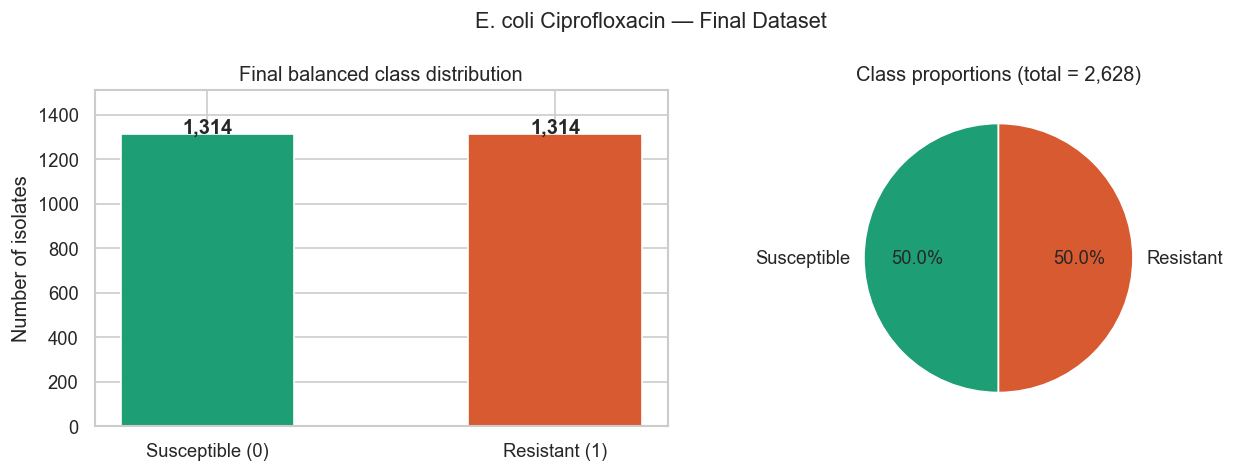

In [19]:
# ── Plot 1: Final class distribution ─────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Bar chart
counts = df_balanced['label'].value_counts()
axes[0].bar(['Susceptible (0)', 'Resistant (1)'],
            [counts[0], counts[1]],
            color=[COLORS['Susceptible'], COLORS['Resistant']],
            width=0.5)
for i, v in enumerate([counts[0], counts[1]]):
    axes[0].text(i, v + 5, f'{v:,}', ha='center', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Number of isolates')
axes[0].set_title('Final balanced class distribution')
axes[0].set_ylim(0, max(counts) * 1.15)

# Pie chart
axes[1].pie([counts[0], counts[1]],
            labels=['Susceptible', 'Resistant'],
            colors=[COLORS['Susceptible'], COLORS['Resistant']],
            autopct='%1.1f%%', startangle=90,
            textprops={'fontsize': 11})
axes[1].set_title(f'Class proportions (total = {len(df_balanced):,})')

plt.suptitle('E. coli Ciprofloxacin — Final Dataset', fontsize=13)
plt.tight_layout()
plt.show()

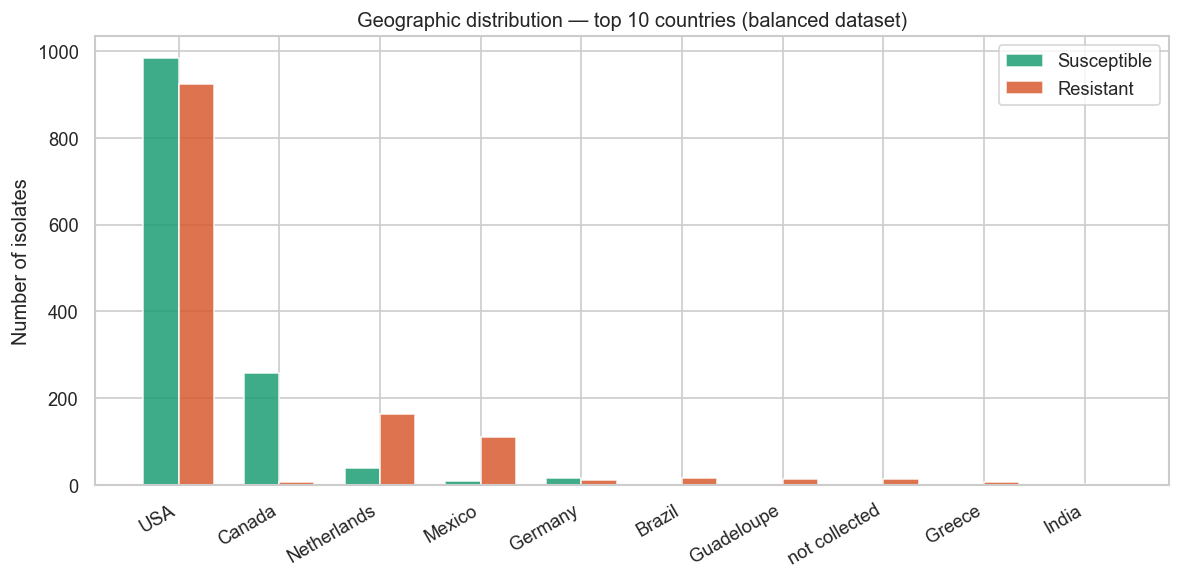


Resistance rate by country (top 10):
               Susceptible  Resistant  Total  Resistance %
Country                                                   
USA                    985        924   1909          48.4
Canada                 258          6    264           2.3
Netherlands             38        164    202          81.2
Mexico                  10        111    121          91.7
Germany                 16         12     28          42.9
Brazil                   2         16     18          88.9
Guadeloupe               0         14     14         100.0
not collected            1         13     14          92.9
Greece                   0          6      6         100.0
India                    0          2      2         100.0


In [20]:
# ── Plot 2: Geographic distribution ──────────────────────────────
country_label = pd.crosstab(df_balanced['Country'], df_balanced['label'])
country_label.columns = ['Susceptible', 'Resistant']
country_label['Total'] = country_label.sum(axis=1)
top_countries = country_label.sort_values('Total', ascending=False).head(10)

fig, ax = plt.subplots(figsize=(10, 5))
x = range(len(top_countries))
w = 0.35
ax.bar([i - w/2 for i in x], top_countries['Susceptible'], w,
       label='Susceptible', color=COLORS['Susceptible'], alpha=0.85)
ax.bar([i + w/2 for i in x], top_countries['Resistant'], w,
       label='Resistant', color=COLORS['Resistant'], alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(top_countries.index, rotation=30, ha='right')
ax.set_ylabel('Number of isolates')
ax.set_title('Geographic distribution — top 10 countries (balanced dataset)')
ax.legend()
plt.tight_layout()
plt.show()

print('\nResistance rate by country (top 10):')
top_countries['Resistance %'] = (top_countries['Resistant'] / top_countries['Total'] * 100).round(1)
print(top_countries[['Susceptible', 'Resistant', 'Total', 'Resistance %']])

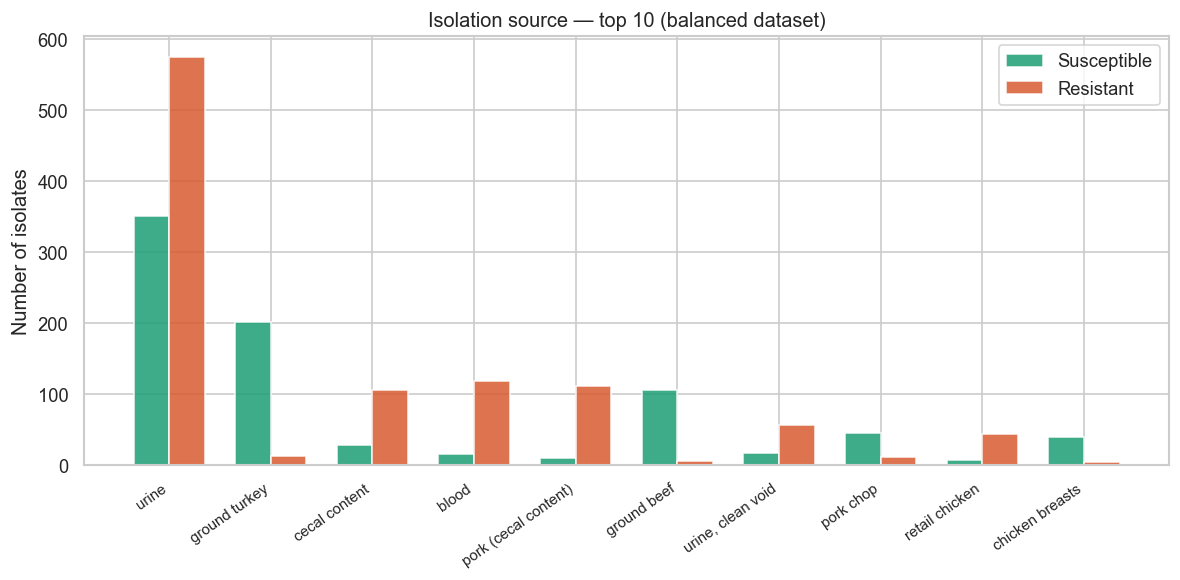

In [21]:
# ── Plot 3: Isolation source distribution ────────────────────────
source_label = pd.crosstab(df_balanced['Isolation source'], df_balanced['label'])
source_label.columns = ['Susceptible', 'Resistant']
source_label['Total'] = source_label.sum(axis=1)
top_sources = source_label.sort_values('Total', ascending=False).head(10)

fig, ax = plt.subplots(figsize=(10, 5))
x = range(len(top_sources))
ax.bar([i - w/2 for i in x], top_sources['Susceptible'], w,
       label='Susceptible', color=COLORS['Susceptible'], alpha=0.85)
ax.bar([i + w/2 for i in x], top_sources['Resistant'], w,
       label='Resistant', color=COLORS['Resistant'], alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(top_sources.index, rotation=35, ha='right', fontsize=9)
ax.set_ylabel('Number of isolates')
ax.set_title('Isolation source — top 10 (balanced dataset)')
ax.legend()
plt.tight_layout()
plt.show()

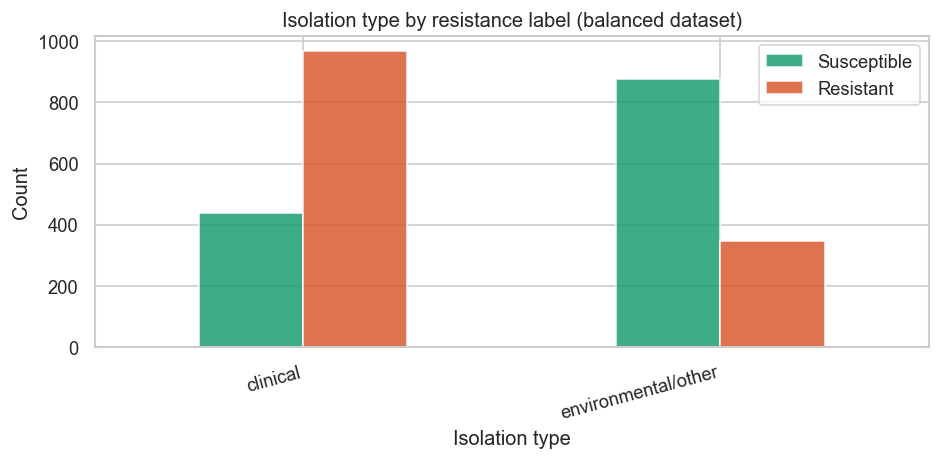

In [22]:
# ── Plot 4: Isolation type (clinical vs food vs environmental) ───
type_counts = df_balanced.groupby(['Isolation type', 'label']).size().unstack(fill_value=0)
type_counts.columns = ['Susceptible', 'Resistant']

type_counts.plot(kind='bar', figsize=(8, 4),
                 color=[COLORS['Susceptible'], COLORS['Resistant']],
                 alpha=0.85)
plt.title('Isolation type by resistance label (balanced dataset)')
plt.xlabel('Isolation type')
plt.ylabel('Count')
plt.xticks(rotation=15, ha='right')
plt.legend()
plt.tight_layout()
plt.show()

In [23]:
# Update these values from your actual script output
pipeline_stages = [
    ('Raw download',              1765,  9607),
    ('After organism filter',     1472,  8203),
    ('After antibiotic filter',   1314,  6284),
    ('After assembly filter',     1314,  5867),
    ('After duplicate removal',   1314,  5867),
    ('After conflict removal',    1314,  5867),
    ('After balancing',           1314,  1314),
]

stages  = [s[0] for s in pipeline_stages]
r_vals  = [s[1] for s in pipeline_stages]
s_vals  = [s[2] for s in pipeline_stages]

# Summary table
summary_df = pd.DataFrame({
    'Stage'      : stages,
    'Resistant'  : r_vals,
    'Susceptible': s_vals,
    'Total'      : [r+s for r,s in zip(r_vals, s_vals)]
})
print(summary_df.to_string(index=False))

                  Stage  Resistant  Susceptible  Total
           Raw download       1765         9607  11372
  After organism filter       1472         8203   9675
After antibiotic filter       1314         6284   7598
  After assembly filter       1314         5867   7181
After duplicate removal       1314         5867   7181
 After conflict removal       1314         5867   7181
        After balancing       1314         1314   2628


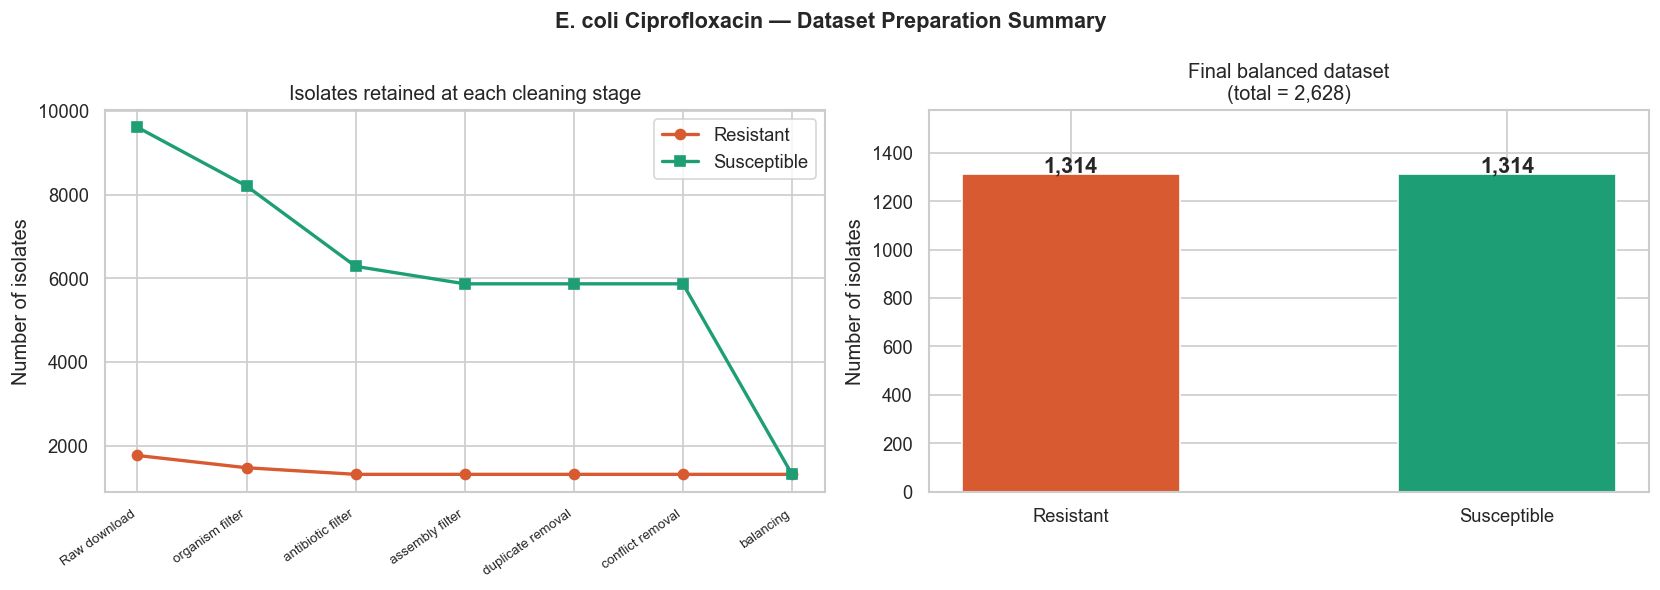

In [24]:
# Funnel visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Line plot — size at each stage
axes[0].plot(range(len(stages)), r_vals, 'o-',
             color=COLORS['Resistant'], lw=2, label='Resistant')
axes[0].plot(range(len(stages)), s_vals, 's-',
             color=COLORS['Susceptible'], lw=2, label='Susceptible')
axes[0].set_xticks(range(len(stages)))
axes[0].set_xticklabels([s.replace('After ', '') for s in stages],
                         rotation=35, ha='right', fontsize=8)
axes[0].set_ylabel('Number of isolates')
axes[0].set_title('Isolates retained at each cleaning stage')
axes[0].legend()

# Bar chart — final state
final_r = r_vals[-1]
final_s = s_vals[-1]
bars = axes[1].bar(['Resistant', 'Susceptible'],
                   [final_r, final_s],
                   color=[COLORS['Resistant'], COLORS['Susceptible']],
                   width=0.5)
for bar, val in zip(bars, [final_r, final_s]):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 5,
                 f'{val:,}', ha='center', fontsize=13, fontweight='bold')
axes[1].set_ylim(0, max(final_r, final_s) * 1.2)
axes[1].set_ylabel('Number of isolates')
axes[1].set_title(f'Final balanced dataset\n(total = {final_r + final_s:,})')

plt.suptitle('E. coli Ciprofloxacin — Dataset Preparation Summary',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()